In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
from google.colab import files

uploaded = files.upload()


Saving airport.csv to airport.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving aircraft.csv to aircraft.csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving flights.csv to flights.csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving delays.csv to delays.csv


In [7]:
airport_df = pd.read_csv("airport.csv")
aircraft_df = pd.read_csv("aircraft.csv")
flights_df = pd.read_csv("flights.csv")
delay_df = pd.read_csv("delays.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


In [8]:
airport_df.head()


,icao_code,iata_code,name,city,country,continent,latitude,longitude,timezone
0,VIDP,DEL,Indira Gandhi International Airport,Delhi,India,Asia,28.5562,77.1000,Asia/Kolkata
1,VABB,BOM,Chhatrapati Shivaji Airport,Mumbai,India,Asia,19.0896,72.8656,Asia/Kolkata
2,VOBL,BLR,Kempegowda International Airport,Bangalore,India,Asia,13.1986,77.7066,Asia/Kolkata
3,VOMM,MAA,Chennai International Airport,Chennai,India,Asia,12.9941,80.1709,Asia/Kolkata


In [9]:
aircraft_df.head()


,registration,model,manufacturer,icao_type_code,owner
0,VTABC,A320,Airbus,A320,Air India
1,VTXYZ,B737,Boeing,B737,Air India
2,VTAAA,A321,Airbus,A321,Indigo
3,VTBBB,A320,Airbus,A320,Vistara


In [10]:
flights_df.head()

,flight_id,flight_number,aircraft_registration,origin_iata,destination_iata,status,airline_code
0,F001,AI101,VTABC,DEL,BOM,On Time,AI
1,F002,AI102,VTXYZ,BOM,DEL,Delayed,AI
2,F003,6E501,VTAAA,DEL,BLR,On Time,6E
3,F004,UK201,VTBBB,BLR,MAA,Cancelled,UK
4,F005,AI301,VTABC,MAA,DEL,Delayed,AI


In [11]:
delay_df.head()

,airport_iata,delay_date,total_flights,delayed_flights,delay_index,median_delay_min,canceled_flights
0,DEL,2026-01-10,120,15,12,18,2
1,BOM,2026-01-10,90,10,11,15,1
2,BLR,2026-01-10,80,8,10,14,0
3,MAA,2026-01-10,75,7,9,12,1


In [12]:
print("Total Airports :", len(airport_df))
print("Total Aircraft :", len(aircraft_df))
print("Total Flights :", len(flights_df))
print("Total Delay Records :", len(delay_df))


Total Airports : 4
Total Aircraft : 4
Total Flights : 5
Total Delay Records : 4


In [13]:
airport_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   icao_code  4 non-null      object 
 1   iata_code  4 non-null      object 
 2   name       4 non-null      object 
 3   city       4 non-null      object 
 4   country    4 non-null      object 
 5   continent  4 non-null      object 
 6   latitude   4 non-null      float64
 7   longitude  4 non-null      float64
 8   timezone   4 non-null      object 
dtypes: float64(2), object(7)
memory usage: 420.0+ bytes


In [14]:
flights_df["status"].value_counts()

,count
status,
On Time,2
Delayed,2
Cancelled,1


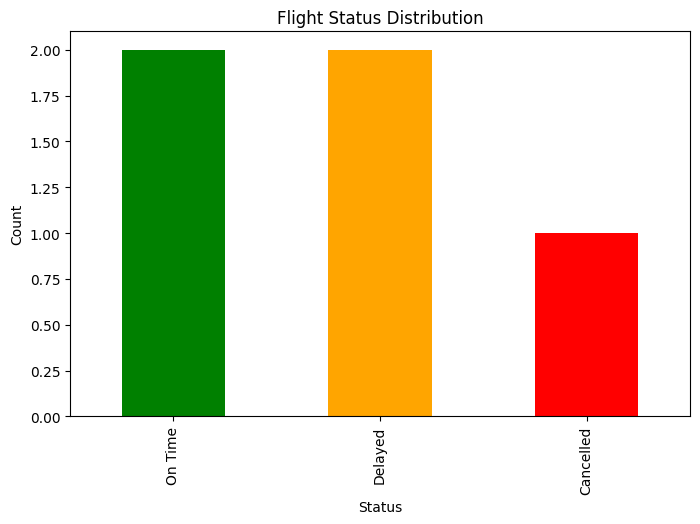

In [15]:
plt.figure(figsize=(8,5))

flights_df["status"].value_counts().plot(
    kind="bar",
    color=["green","orange","red"]
)

plt.title("Flight Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

In [16]:
flights_df["airline_code"].value_counts()

,count
airline_code,
AI,3
6E,1
UK,1


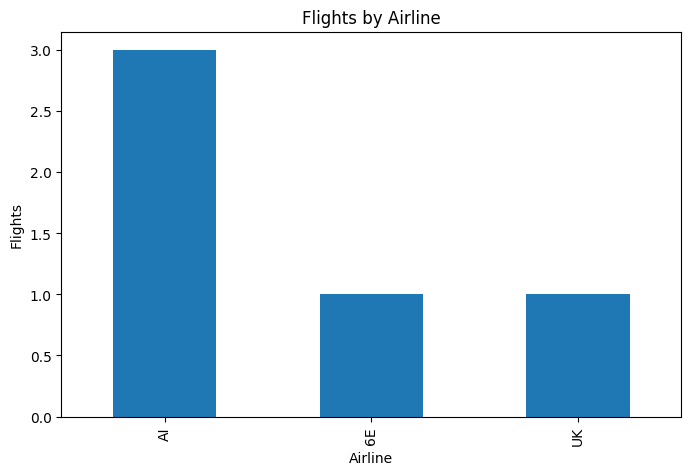

In [17]:
plt.figure(figsize=(8,5))

flights_df["airline_code"].value_counts().plot(
    kind="bar"
)

plt.title("Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Flights")

plt.show()

In [18]:
delay_df

,airport_iata,delay_date,total_flights,delayed_flights,delay_index,median_delay_min,canceled_flights
0,DEL,2026-01-10,120,15,12,18,2
1,BOM,2026-01-10,90,10,11,15,1
2,BLR,2026-01-10,80,8,10,14,0
3,MAA,2026-01-10,75,7,9,12,1


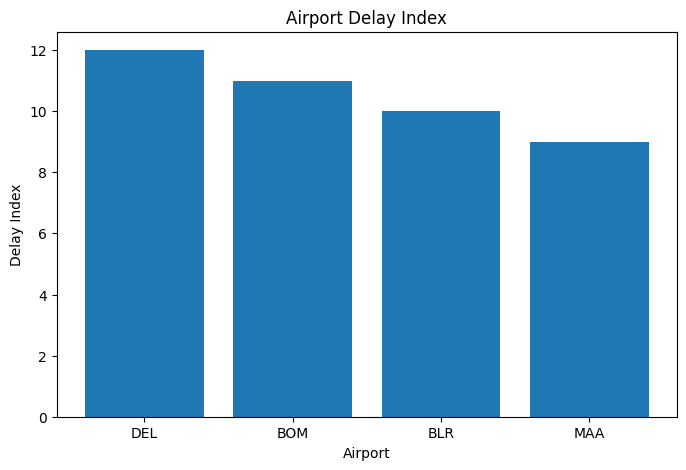

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    delay_df["airport_iata"],
    delay_df["delay_index"]
)

plt.title("Airport Delay Index")
plt.xlabel("Airport")
plt.ylabel("Delay Index")

plt.show()

In [20]:
route_count = flights_df.groupby(
    ["origin_iata","destination_iata"]
).size().reset_index(name="Flights")

route_count

,origin_iata,destination_iata,Flights
0,BLR,MAA,1
1,BOM,DEL,1
2,DEL,BLR,1
3,DEL,BOM,1
4,MAA,DEL,1


In [21]:
merged = flights_df.merge(
    aircraft_df,
    left_on="aircraft_registration",
    right_on="registration"
)

merged[["flight_number","model"]]

,flight_number,model
0,AI101,A320
1,AI102,B737
2,6E501,A321
3,UK201,A320
4,AI301,A320


In [22]:
merged["model"].value_counts()


,count
model,
A320,3
B737,1
A321,1


In [23]:
print("Project Insights")

print("- Airport and flight data successfully analyzed")
print("- Flight statuses evaluated")
print("- Delay trends identified")
print("- Aircraft utilization analyzed")
print("- Route performance reviewed")

Project Insights
- Airport and flight data successfully analyzed
- Flight statuses evaluated
- Delay trends identified
- Aircraft utilization analyzed
- Route performance reviewed
